# Comparação dos Resultados dos Modelos

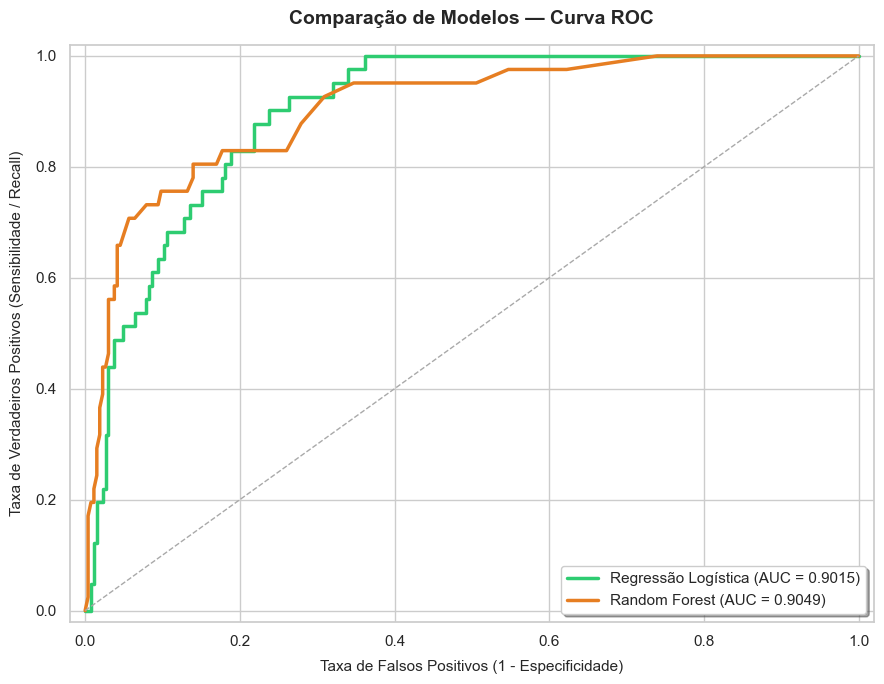


                 DESEMPENHO: REGRESSÃO LOGÍSTICA)                
                 precision    recall  f1-score   support

Qualidade Comum       0.98      0.74      0.84       265
 Alta Qualidade       0.35      0.90      0.50        41

       accuracy                           0.76       306
      macro avg       0.66      0.82      0.67       306
   weighted avg       0.90      0.76      0.80       306


                    DESEMPENHO: RANDOM FOREST                    
                 precision    recall  f1-score   support

Qualidade Comum       0.95      0.94      0.95       265
 Alta Qualidade       0.66      0.71      0.68        41

       accuracy                           0.91       306
      macro avg       0.81      0.83      0.82       306
   weighted avg       0.91      0.91      0.91       306



In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, roc_auc_score, classification_report

# ==============================================================================
# 1. CARREGAMENTO DOS DADOS DOS NOTEBOOKS ANTERIORES
# ==============================================================================

# Lendo os dados salvos pelos outros notebooks
lr_dados = pd.read_csv('../data/resultados_logistica.csv')
rf_dados = pd.read_csv('../data/resultados_random_forest.csv')

# Mapeando para as variáveis do código de comparação
y_test = lr_dados['y_real']
y_prob_ot = lr_dados['y_prob_lr']
y_pred_thresh = lr_dados['y_pred_lr']

y_scores_original = rf_dados['y_prob_rf']
y_pred_definitivo = rf_dados['y_pred_rf']


# ==============================================================================
# 2. GRÁFICO COMPARATIVO DA CURVA ROC
# ==============================================================================
plt.figure(figsize=(9, 7))
sns.set_theme(style="whitegrid")

# --- Curva ROC: Regressão Logística ---
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_ot)
auc_lr = roc_auc_score(y_test, y_prob_ot)
plt.plot(fpr_lr, tpr_lr, color='#2ecc71', lw=2.5, label=f'Regressão Logística (AUC = {auc_lr:.4f})')

# --- Curva ROC: Random Forest ---
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_scores_original)
auc_rf = roc_auc_score(y_test, y_scores_original)
plt.plot(fpr_rf, tpr_rf, color='#e67e22', lw=2.5, label=f'Random Forest (AUC = {auc_rf:.4f})')

# Linha de referência diagonal (classificador aleatório)
plt.plot([0, 1], [0, 1], color='darkgray', linestyle='--', lw=1)

# Customização estética do gráfico
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.xlabel('Taxa de Falsos Positivos (1 - Especificidade)', fontsize=11, labelpad=8)
plt.ylabel('Taxa de Verdadeiros Positivos (Sensibilidade / Recall)', fontsize=11, labelpad=8)
plt.title('Comparação de Modelos — Curva ROC', fontsize=14, fontweight='bold', pad=15)
plt.legend(loc='lower right', fontsize=11, frameon=True, shadow=True)
plt.tight_layout()
plt.show()


# ==============================================================================
# 3. RELATÓRIOS DE CLASSIFICAÇÃO (MÉTRICAS DETALHADAS)
# ==============================================================================
largura_bloco = 65

print("\n" + "=" * largura_bloco)
print("DESEMPENHO: REGRESSÃO LOGÍSTICA)".center(largura_bloco))
print("=" * largura_bloco)
print(classification_report(y_test, y_pred_thresh, target_names=['Qualidade Comum', 'Alta Qualidade']))

print("\n" + "=" * largura_bloco)
print("DESEMPENHO: RANDOM FOREST".center(largura_bloco))
print("=" * largura_bloco)
print(classification_report(y_test, y_pred_definitivo, target_names=['Qualidade Comum', 'Alta Qualidade']))
print("=" * largura_bloco)